In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
 
print("Imports done ✓")

Imports done ✓


In [14]:
train = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\train.csv')
test  = pd.read_csv(r'C:\git\machine learning\house-price-prediction\data\processed\test.csv')
 
# Separate features and target
X_train = train.drop(columns=['SalePrice']).values   # .values → numpy matrix
X_test  = test.drop(columns=['SalePrice']).values
 
y_train = train['SalePrice'].values
y_test  = test['SalePrice'].values
 
feature_names = train.drop(columns=['SalePrice']).columns.tolist()
 
print(f"X_train : {X_train.shape}  →  {X_train.shape[1]} features, {X_train.shape[0]} rows")
print(f"X_test  : {X_test.shape}")
 
# Save Phase 4 R² so we can compare later
r2_simple_lr = 0.6441   # ← paste your actual Phase 4 R² here
 

X_train : (2341, 188)  →  188 features, 2341 rows
X_test  : (586, 188)


In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [25]:
sk_model = LinearRegression()
sk_model.fit(X_train, y_train)
 
y_pred_train_sk = sk_model.predict(X_train)
y_pred_test_sk  = sk_model.predict(X_test)
 
rmse_train_sk = np.sqrt(mean_squared_error(y_train, y_pred_train_sk))
rmse_test_sk  = np.sqrt(mean_squared_error(y_test,  y_pred_test_sk))
r2_train_sk   = r2_score(y_train, y_pred_train_sk)
r2_test_sk    = r2_score(y_test,  y_pred_test_sk)
 
print("── sklearn Multiple LR ──────────────────────")
print(f"  Train RMSE : {rmse_train_sk:.4f}  |  Train R² : {r2_train_sk:.4f}")
print(f"  Test  RMSE : {rmse_test_sk:.4f}  |  Test  R² : {r2_test_sk:.4f}")
print()
print(f"  Phase 4 (Simple LR, 1 feature) R²  : {r2_simple_lr:.4f}")
print(f"  Phase 5 (Multiple LR, all features) : {r2_test_sk:.4f}")
print(f"  Improvement : +{r2_test_sk - r2_simple_lr:.4f}")

── sklearn Multiple LR ──────────────────────
  Train RMSE : 0.1022  |  Train R² : 0.9358
  Test  RMSE : 0.0926  |  Test  R² : 0.9522

  Phase 4 (Simple LR, 1 feature) R²  : 0.6441
  Phase 5 (Multiple LR, all features) : 0.9522
  Improvement : +0.3081


In [26]:
#  In Simple LR we used a 1D formula.
#  With many features, we use matrix math instead.
#
#  Normal Equation:  β = (XᵀX)⁻¹ Xᵀy
#
#  Step by step:
#    1. Add a column of 1s to X  → this handles the intercept β₀
#    2. Compute XᵀX              → (features × features) matrix
#    3. Compute its inverse       → (XᵀX)⁻¹
#    4. Multiply: β = (XᵀX)⁻¹ Xᵀy
# ────────────────────────────────────────────────────────────────
 
# Step 1 — Add column of 1s (bias term) to the LEFT of X
# This allows the formula to compute β₀ automatically
ones       = np.ones((X_train.shape[0], 1))          # column of 1s
X_train_b  = np.hstack([ones, X_train])               # shape: (n_samples, n_features+1)
 
ones_test  = np.ones((X_test.shape[0], 1))
X_test_b   = np.hstack([ones_test, X_test])
 
# Step 2 & 3 & 4 — Normal Equation: β = (XᵀX)⁻¹ Xᵀy
XtX        = X_train_b.T @ X_train_b                  # Xᵀ X  (matrix multiplication)
XtX_inv    = np.linalg.pinv(XtX)                      # (XᵀX)⁻¹  using pseudo-inverse (more stable)
Xty        = X_train_b.T @ y_train                    # Xᵀ y
beta       = XtX_inv @ Xty                             # final β vector
 
# beta[0] = intercept, beta[1:] = coefficients for each feature
beta0_ols  = beta[0]
beta_rest  = beta[1:]
 
print(f"── OLS Matrix Form from Scratch ─────────────")
print(f"  Intercept β₀     : {beta0_ols:.6f}")
print(f"  Number of βs     : {len(beta_rest)}  (one per feature)")
print(f"  First 5 βs       : {beta_rest[:5].round(6)}")
 

── OLS Matrix Form from Scratch ─────────────
  Intercept β₀     : 10.777291
  Number of βs     : 188  (one per feature)
  First 5 βs       : [-0.012686  0.00513   0.044332  0.001637  0.07256 ]


In [27]:
# Predict: ŷ = X_b @ β  (matrix multiplication does β₀ + β₁x₁ + β₂x₂ ...)
y_pred_train_ols = X_train_b @ beta
y_pred_test_ols  = X_test_b  @ beta
 
rmse_train_ols = np.sqrt(np.mean((y_train - y_pred_train_ols) ** 2))
rmse_test_ols  = np.sqrt(np.mean((y_test  - y_pred_test_ols)  ** 2))
 
ss_res = np.sum((y_test - y_pred_test_ols) ** 2)
ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
r2_ols = 1 - (ss_res / ss_tot)
 
print("── OLS Matrix (from scratch) Metrics ────────")
print(f"  Train RMSE : {rmse_train_ols:.4f}")
print(f"  Test  RMSE : {rmse_test_ols:.4f}")
print(f"  Test  R²   : {r2_ols:.4f}")
print()
 
# Verify they match sklearn
print("── Verification vs sklearn ──────────────────")
print(f"  sklearn  β₀ : {sk_model.intercept_:.6f}")
print(f"  OLS      β₀ : {beta0_ols:.6f}")
print(f"  Match ✓" if abs(sk_model.intercept_ - beta0_ols) < 0.001 else "  Mismatch — check your code")
 

── OLS Matrix (from scratch) Metrics ────────
  Train RMSE : 0.1022
  Test  RMSE : 0.0926
  Test  R²   : 0.9522

── Verification vs sklearn ──────────────────
  sklearn  β₀ : 10.777291
  OLS      β₀ : 10.777291
  Match ✓


In [28]:
#  Problem with R²:  adding ANY feature (even random noise)
#  always increases R² a little bit.
#  That makes R² misleading when comparing models with different
#  numbers of features.
#
#  Adjusted R² fixes this by PENALISING extra features:
#
#  Adj R² = 1 - [ (1 - R²)(n - 1) / (n - k - 1) ]
#    n = number of samples
#    k = number of features
# ────────────────────────────────────────────────────────────────
 
n_test = len(y_test)
k      = X_test.shape[1]   # number of features
 
adj_r2 = 1 - (1 - r2_ols) * (n_test - 1) / (n_test - k - 1)
 
print(f"── Adjusted R² ──────────────────────────────")
print(f"  n (test samples)  : {n_test}")
print(f"  k (features)      : {k}")
print(f"  R²                : {r2_ols:.4f}")
print(f"  Adjusted R²       : {adj_r2:.4f}")
print()
print(f"  If Adj R² << R², you have too many useless features.")
print(f"  Difference here   : {r2_ols - adj_r2:.4f}")
 

── Adjusted R² ──────────────────────────────
  n (test samples)  : 586
  k (features)      : 188
  R²                : 0.9522
  Adjusted R²       : 0.9296

  If Adj R² << R², you have too many useless features.
  Difference here   : 0.0226


── Top 15 Most Impactful Features ───────────
               Feature  Coefficient
          MS Zoning_FV     0.830256
          MS Zoning_RH     0.827246
          MS Zoning_RL     0.805991
          MS Zoning_RM     0.773473
     MS Zoning_I (all)     0.692786
     MS Zoning_C (all)     0.603633
   Exterior 1st_CBlock     0.527307
  Neighborhood_GrnHill     0.411597
   Mas Vnr Type_CBlock    -0.392975
  Exterior 2nd_PreCast     0.238466
  Exterior 1st_PreCast     0.238466
Sale Condition_AdjLand     0.222285
  Exterior 1st_BrkFace     0.196314
  Exterior 1st_BrkComm     0.189448
   Exterior 2nd_CBlock    -0.172181


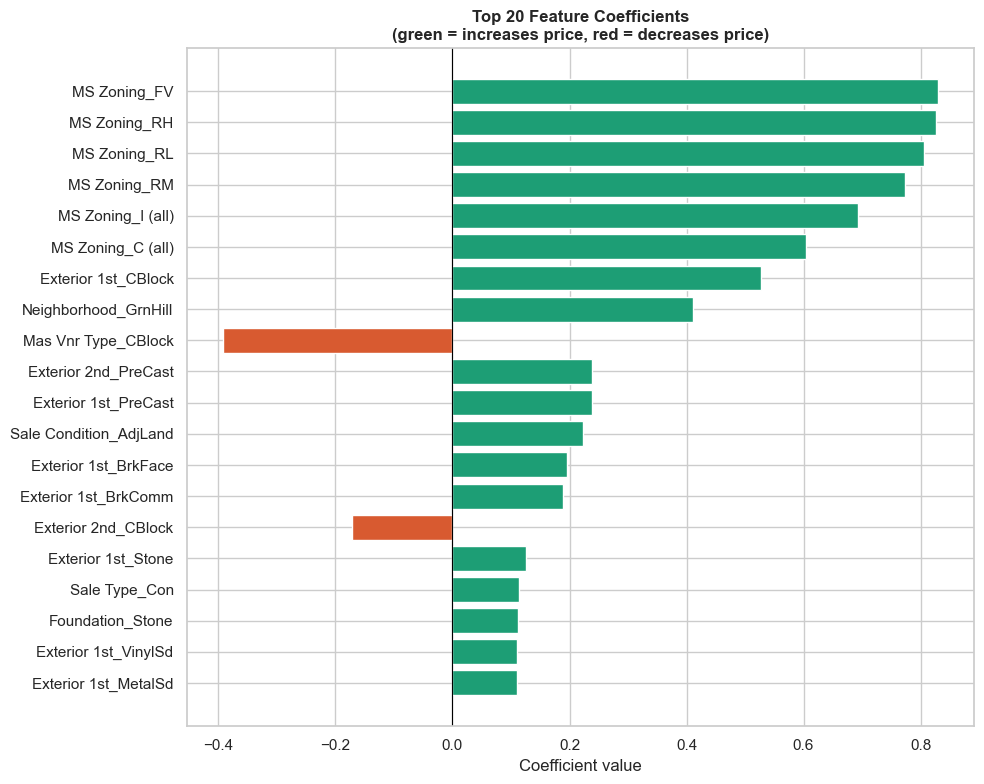

In [29]:
# Each β tells us:
# "if this feature goes up by 1 (scaled unit), how does log(SalePrice) change?"
# Positive β → feature increases price
# Negative β → feature decreases price
 
coeff_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': sk_model.coef_
})
 
# Sort by absolute value to find the most impactful features
coeff_df['Abs Coefficient'] = coeff_df['Coefficient'].abs()
coeff_df = coeff_df.sort_values('Abs Coefficient', ascending=False).reset_index(drop=True)
 
print("── Top 15 Most Impactful Features ───────────")
print(coeff_df[['Feature', 'Coefficient']].head(15).to_string(index=False))
 
# --- Plot top 20 coefficients ---
top20 = coeff_df.head(20)
 
plt.figure(figsize=(10, 8))
colors = ['#1D9E75' if c > 0 else '#D85A30' for c in top20['Coefficient']]
plt.barh(top20['Feature'], top20['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coefficient value')
plt.title('Top 20 Feature Coefficients\n(green = increases price, red = decreases price)',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\13_coefficients.png',
            dpi=150, bbox_inches='tight')
plt.show()
 

── VIF Analysis ─────────────────────────────
(VIF > 10 = serious multicollinearity)

               Feature         VIF
  Exterior 2nd_PreCast         inf
  Exterior 1st_PreCast         inf
          Heating_GasA 1478.496620
          MS Zoning_RL 1187.912458
          MS Zoning_RM  247.165732
      Roof Style_Gable  164.239712
  Exterior 2nd_VinylSd  143.677780
  Exterior 1st_VinylSd  142.816943
     Mas Vnr Type_None  123.686182
    Garage Type_Attchd  102.335112
          MS Zoning_FV   77.797809
  Exterior 2nd_MetalSd   69.217875
  Exterior 1st_MetalSd   67.802438
  Exterior 1st_HdBoard   54.940328
  Exterior 2nd_HdBoard   51.103303
  Exterior 1st_Wd Sdng   48.216902
  Exterior 2nd_Wd Sdng   47.740414
         Sale Type_New   47.453177
    Garage Type_Detchd   45.298280
Sale Condition_Partial   45.001214


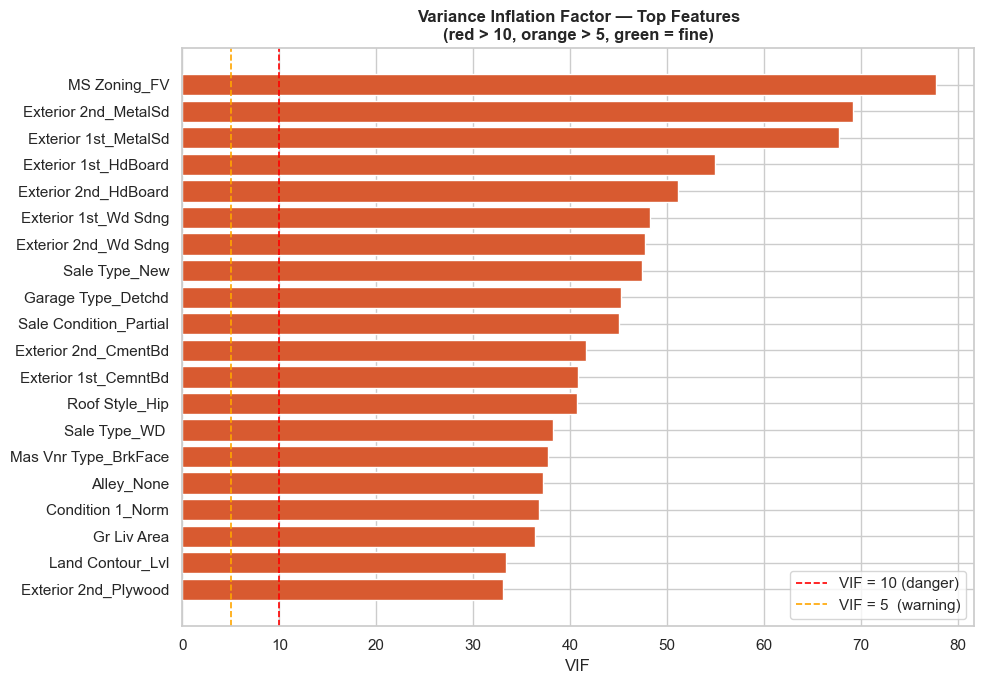


Features with VIF > 10 : 62
These will be handled by Ridge/Lasso regularisation in Phase 8


In [30]:
#  Multicollinearity = two or more features are strongly correlated.
#  Problem: the model can't figure out which feature is doing the work.
#           Coefficients become unstable and unreliable.
#
#  VIF (Variance Inflation Factor) measures this:
#    VIF = 1            → no multicollinearity (perfect)
#    VIF between 1–5    → acceptable
#    VIF between 5–10   → moderate, watch out
#    VIF > 10           → serious problem
#
#  How VIF works internally:
#    For each feature Xⱼ, regress it on ALL other features.
#    Compute R² of that regression.
#    VIF = 1 / (1 - R²)
#    High R² → feature is easily predicted by others → high VIF
# ────────────────────────────────────────────────────────────────
 
# VIF needs a DataFrame with only numerical columns
# We use training data (as DataFrame)
X_train_df = pd.DataFrame(X_train, columns=feature_names)
 
# Compute VIF for every feature
# variance_inflation_factor(X, i) → VIF for column i
vif_data = pd.DataFrame()
vif_data['Feature'] = feature_names
vif_data['VIF']     = [variance_inflation_factor(X_train_df.values, i)
                        for i in range(X_train_df.shape[1])]
 
# Sort by VIF descending
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
 
print("── VIF Analysis ─────────────────────────────")
print("(VIF > 10 = serious multicollinearity)\n")
print(vif_data.head(20).to_string(index=False))
 
# --- Plot VIF for top offenders ---
top_vif = vif_data[vif_data['VIF'] < 100].head(20)   # cap extreme values for clean plot
 
plt.figure(figsize=(10, 7))
bar_colors = ['#D85A30' if v > 10 else '#EF9F27' if v > 5 else '#1D9E75'
              for v in top_vif['VIF']]
plt.barh(top_vif['Feature'], top_vif['VIF'], color=bar_colors)
plt.axvline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF = 10 (danger)')
plt.axvline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF = 5  (warning)')
plt.xlabel('VIF')
plt.title('Variance Inflation Factor — Top Features\n(red > 10, orange > 5, green = fine)',
          fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\14_vif.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
high_vif = vif_data[vif_data['VIF'] > 10]
print(f"\nFeatures with VIF > 10 : {len(high_vif)}")
print("These will be handled by Ridge/Lasso regularisation in Phase 8")
 

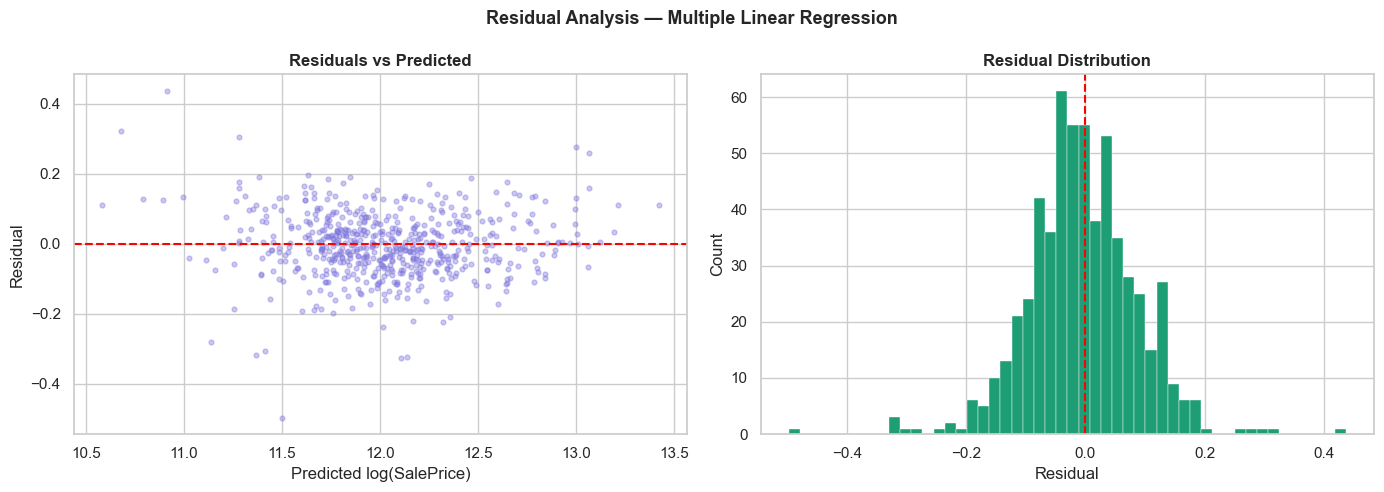

Mean of residuals : -0.004366  (should be ≈ 0)
Std  of residuals : 0.0925


In [31]:
residuals = y_test - y_pred_test_ols
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
# Plot 1 — Residuals vs Predicted values
axes[0].scatter(y_pred_test_ols, residuals, alpha=0.4, color='#7F77DD', s=12)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')
 
# Plot 2 — Residual distribution (should look like a bell curve)
axes[1].hist(residuals, bins=50, color='#1D9E75', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
 
plt.suptitle('Residual Analysis — Multiple Linear Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(r'C:\git\machine learning\house-price-prediction\reports\figures\15_mlr_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()
 
print(f"Mean of residuals : {residuals.mean():.6f}  (should be ≈ 0)")
print(f"Std  of residuals : {residuals.std():.4f}")
 

In [32]:
print("=" * 55)
print("         PHASE 4  vs  PHASE 5 COMPARISON")
print("=" * 55)
print(f"{'Model':<28} {'Features':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 55)
print(f"{'Simple LR (Phase 4)':<28} {'1':>8} {'—':>8} {r2_simple_lr:>8.4f}")
print(f"{'Multiple LR (Phase 5)':<28} {k:>8} {rmse_test_ols:>8.4f} {r2_ols:>8.4f}")
print(f"{'Multiple LR — Adj R²':<28} {k:>8} {'—':>8} {adj_r2:>8.4f}")
print("=" * 55)
print()
print("Key takeaways:")
print(f"  → Adding all features improved R² by {r2_ols - r2_simple_lr:+.4f}")
print(f"  → {len(high_vif)} features have VIF > 10 (multicollinearity)")
print(f"  → Regularisation (Phase 8) will fix multicollinearity")
print(f"  → Next: test the LINE assumptions → Phase 6")


         PHASE 4  vs  PHASE 5 COMPARISON
Model                        Features     RMSE       R²
-------------------------------------------------------
Simple LR (Phase 4)                 1        —   0.6441
Multiple LR (Phase 5)             188   0.0926   0.9522
Multiple LR — Adj R²              188        —   0.9296

Key takeaways:
  → Adding all features improved R² by +0.3081
  → 62 features have VIF > 10 (multicollinearity)
  → Regularisation (Phase 8) will fix multicollinearity
  → Next: test the LINE assumptions → Phase 6
